# Clustering Individuals Based on Eating Habits and Lifestyle


# Notebook Title : Exploratory Data Analysis 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_raw=pd.read_csv("C:/Users/ASUS/Desktop/Fac/Obesity_Clustering_Project/Data/raw/obesity_raw.csv")

In [3]:
print(f' Data shape :  Rows {df_raw.shape[0]} && Columns:{df_raw.shape[1]} \n')

print("*"*30)

print('\nData Types:')
print(df_raw.dtypes)

print("*"*30)

print('\nData Columns:')
print(df_raw.columns.tolist())


 Data shape :  Rows 2174 && Columns:17 

******************************

Data Types:
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                                object
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object
******************************

Data Columns:
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 

In [4]:
df_raw.describe()

,Age,Height,Weight,FCVC,CH2O,FAF,TUE
count,2064.000000,2043.000000,2090.000000,2089.000000,2065.000000,2020.000000,2174.000000
mean,24.442956,3.374361,87.218474,2.421495,2.016164,1.027546,0.656962
std,7.974040,16.851518,30.034987,0.534372,0.609317,0.954291,0.608558
min,0.000000,1.480000,5.000000,1.000000,1.000000,-3.000000,0.000000
25%,19.947666,1.630000,66.000000,2.000000,1.613829,0.129721,0.000000
50%,22.771307,1.700996,83.059034,2.397284,2.000000,1.000000,0.625360
75%,26.000000,1.770000,108.249378,3.000000,2.487919,1.667464,1.000000
max,200.000000,188.277900,600.000000,3.000000,3.000000,15.000000,2.000000


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2174 entries, 0 to 2173
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2174 non-null   object 
 1   Age                             2064 non-null   float64
 2   Height                          2043 non-null   float64
 3   Weight                          2090 non-null   float64
 4   family_history_with_overweight  2174 non-null   object 
 5   FAVC                            2174 non-null   object 
 6   FCVC                            2089 non-null   float64
 7   NCP                             2173 non-null   object 
 8   CAEC                            2044 non-null   object 
 9   SMOKE                           2174 non-null   object 
 10  CH2O                            2065 non-null   float64
 11  SCC                             2107 non-null   object 
 12  FAF                             20

In [6]:
# Categorical columns
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}\n')

for col in cat_cols:
    print(f'**********{col}************')
    print(df_raw[col].unique())
    print()

Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'NCP', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

**********Gender************
['Female' 'Male' 'F' 'MALE' 'male ' ' Female' 'M' 'female']

**********family_history_with_overweight************
['yes' 'no']

**********FAVC************
['yes' 'no' 'YES' 'No ' 'no ']

**********NCP************
['3.0' '1.999014' '4.0' '1.0' '1.709546' '3.56544' '1.706551' '1.92822'
 '3.21043' '2.720642' '1.046144' '3.999591' '2.77684' '2.040582'
 '3.612941' '1.250548' '1.124977' '2.622055' '2.057935' '3.156153'
 '2.138375' '1.089048' '2.996444' '2.849347' '2.105616' '3.03779'
 '2.18162' '3.986652' '2.37985' '2.415522' '2.870661' '2.187145'
 '2.157164' '1.478334' '3.285167' '2.986637' '1.001383' '1.130751'
 '1.044628' '2.256119' '3.193671' '2.99321' '3.070386' '1.00061'
 '3.165837' '2.832018' '3.554974' '3.304123' '2.27374' '2.547086'
 '1.854536' '2.376374' '3.45259' '2.454432' '1.734762' '2.89292'
 '3.891994' '1.116401'

In [7]:
#missing values
df_raw.isnull().sum()

Gender                              0
Age                               110
Height                            131
Weight                             84
family_history_with_overweight      0
FAVC                                0
FCVC                               85
NCP                                 1
CAEC                              130
SMOKE                               0
CH2O                              109
SCC                                67
FAF                               154
TUE                                 0
CALC                              108
MTRANS                             88
NObeyesdad                          0
dtype: int64

In [8]:
#duplicate values
df_raw.duplicated().sum()

np.int64(66)

In [9]:
#Numerical Cols exploration
num_cols=['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']

for col in num_cols:
    df_raw[col]=pd.to_numeric(df_raw[col] , errors='coerce')

df_raw[num_cols].isnull().sum()

Age       110
Height    131
Weight     84
FCVC       85
NCP         5
CH2O      109
FAF       154
TUE         0
dtype: int64

Num Cols Distributions

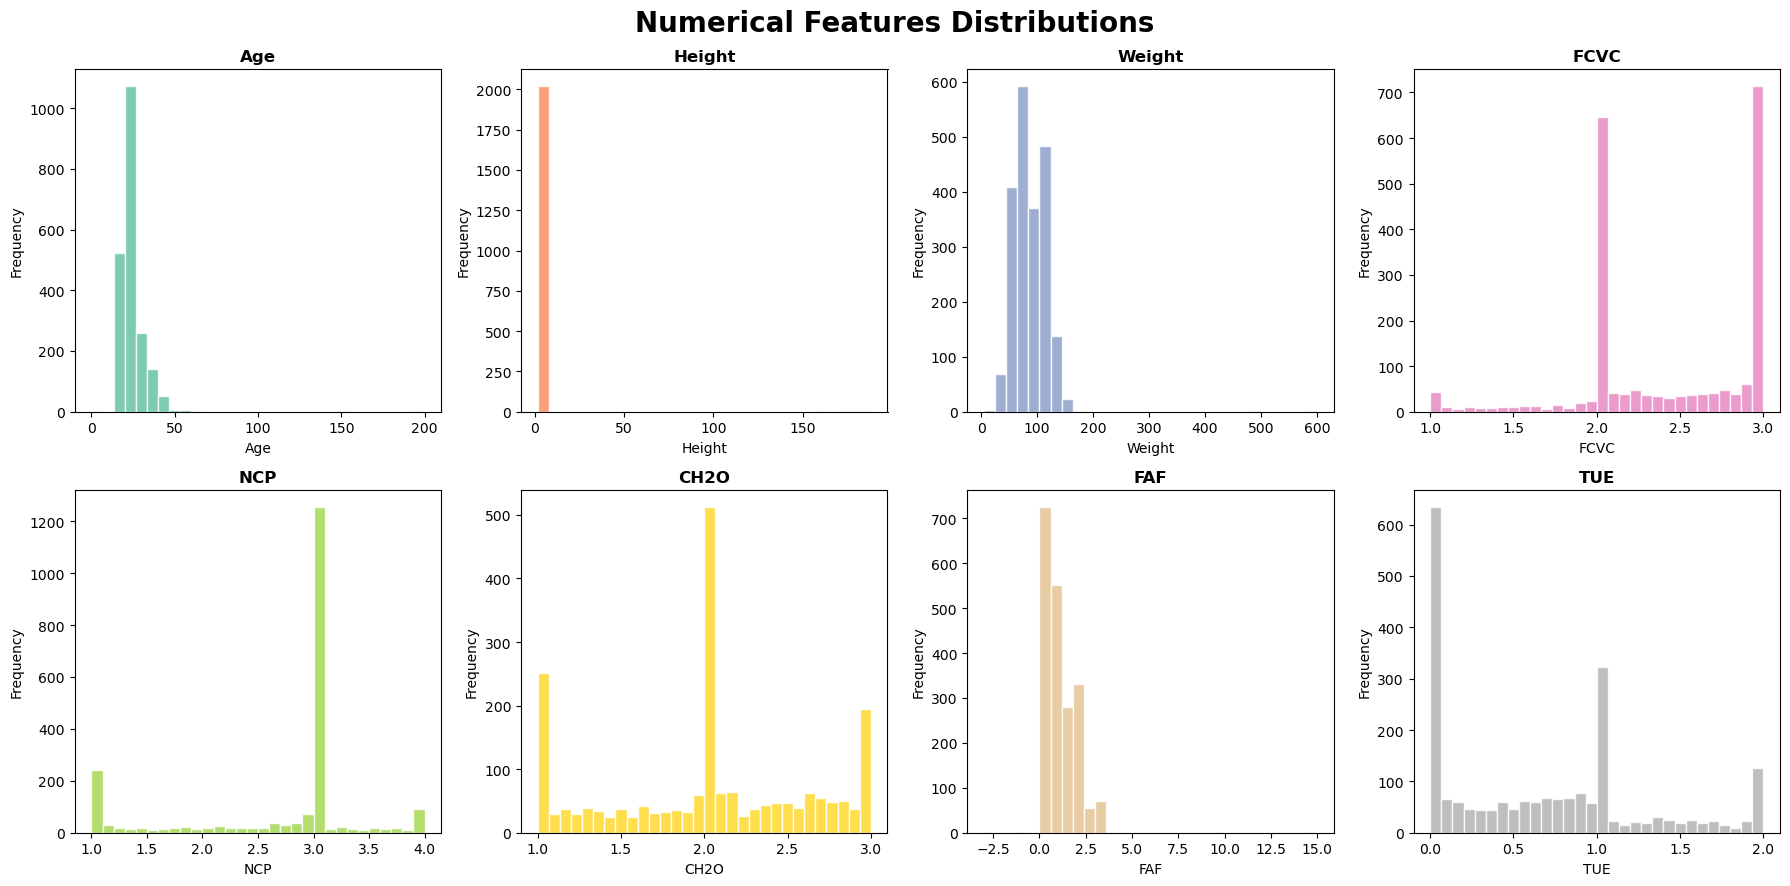

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
colors = sns.color_palette('Set2', len(num_cols))

# numerical column plots
for ax, col, color in zip(axes, num_cols, colors):
    ax.hist(df_raw[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Numerical Features Distributions', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
df_raw.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

Catego cols distribution

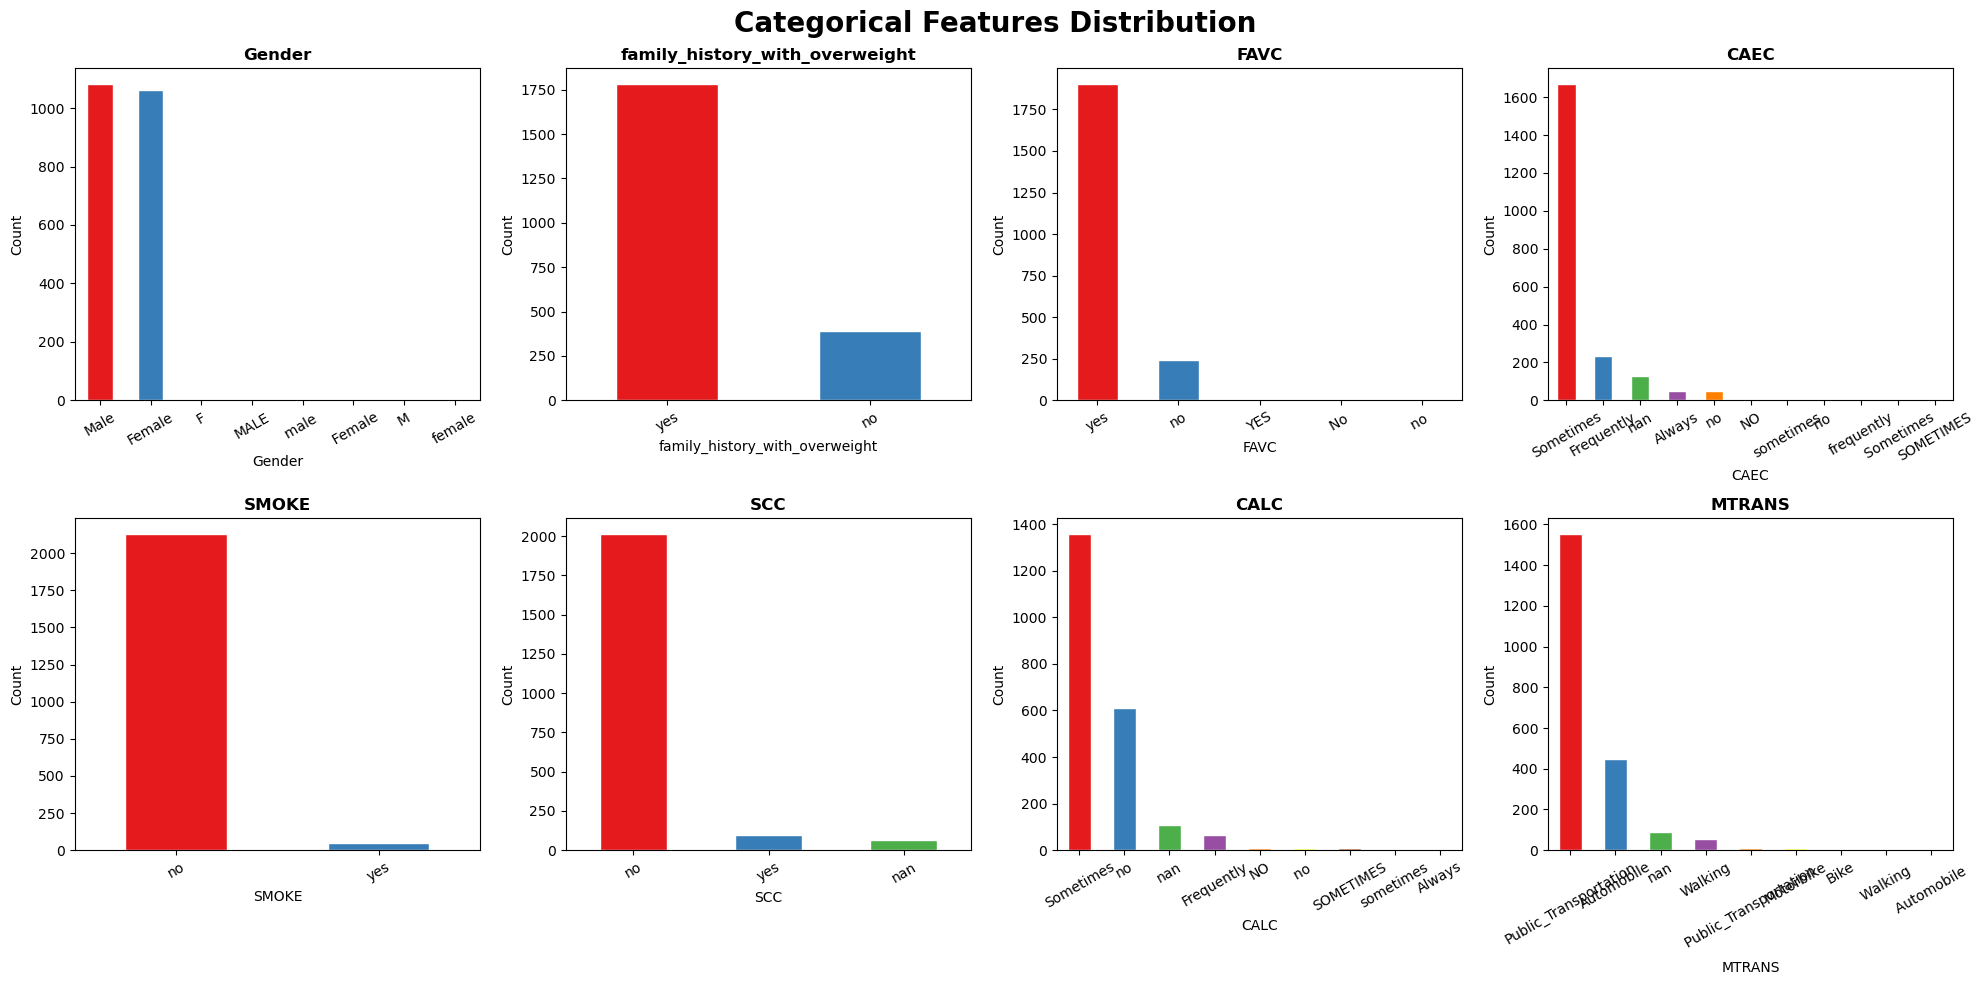

In [12]:
cat_cols = df_raw.select_dtypes(include='object').drop(columns='NObeyesdad')

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
palette = sns.color_palette('Set1')

for ax, col in zip(axes, cat_cols.columns):
    df_raw[col].value_counts(dropna=False).plot(
        kind='bar', ax=ax, color=palette, edgecolor='white'
    )
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Features Distribution', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

Target Distribution 'NObeyesdad'

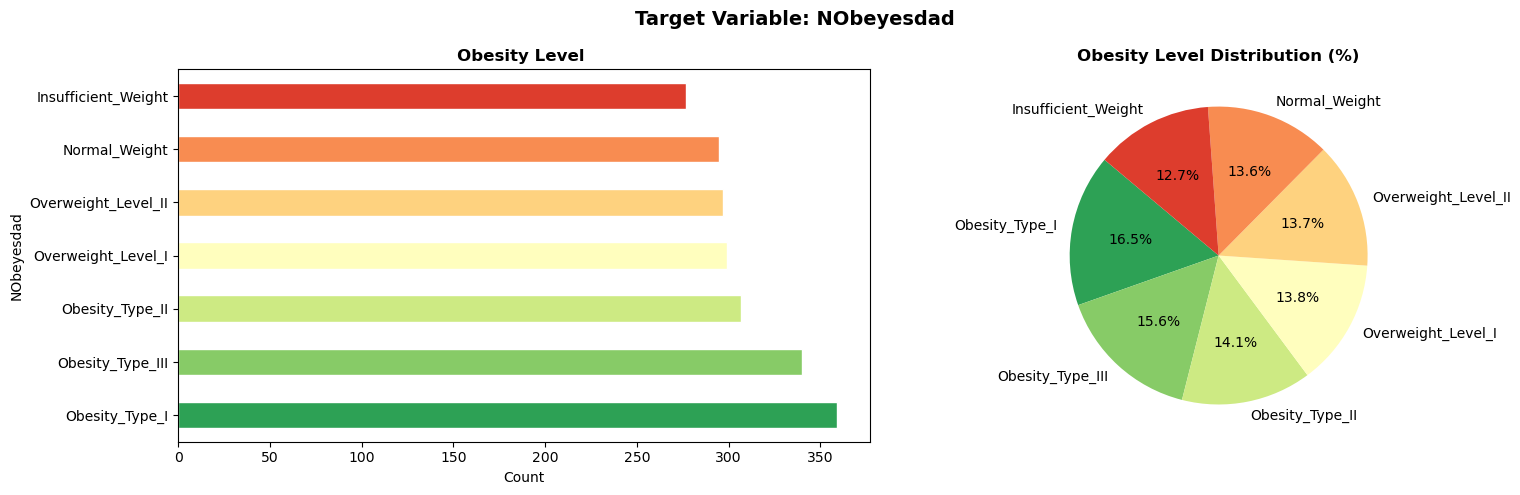

In [13]:
obesity_counts = df_raw['NObeyesdad'].value_counts()
colors = sns.color_palette('RdYlGn_r', len(obesity_counts))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#bar plot
obesity_counts.plot(kind='barh', color=colors, edgecolor='white', ax=axes[0])
axes[0].set_title('Obesity Level ', fontweight='bold')
axes[0].set_xlabel('Count')

#Pie chart
axes[1].pie(obesity_counts, labels=obesity_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Obesity Level Distribution (%)', fontweight='bold')

plt.suptitle('Target Variable: NObeyesdad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Correlation btw features

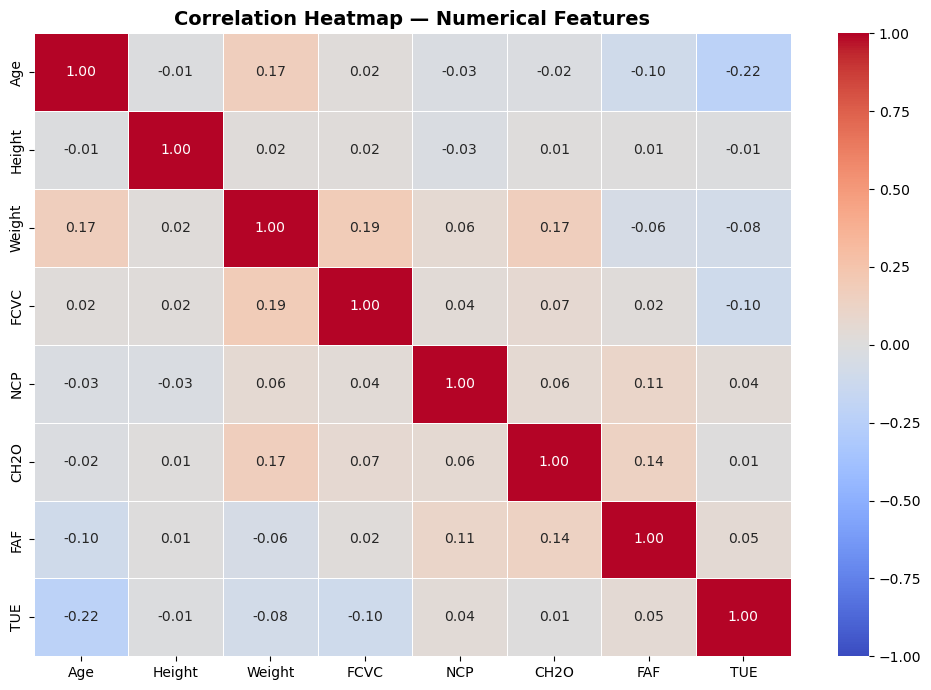

In [14]:
corr = df_raw[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, 
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

------->this shows that all num cols are low correlated